# JURNAL PCD MODUL 2: EKUALISASI DAN SPESIFIKASI HISTOGRAM
Kanaya Salsabila Humaira - F1D02410061

# LIBRARY
Mendeklarasikan library numpy, matplotlib, dan cv2. Numpy berguna untuk melakukan operasi matematika dan pengolahan array multidimensi secara efisien. Matplotlib digunakan untuk menampilkan citra digital serta visualisasi histogram guna menganalisis distribusi intensitas piksel pada gambar. Sedangkan cv2 digunakan dalam proses pengolahan citra digital, seperti konversi ruang warna menggunakan fungsi cvtColor, filtering, transformasi citra, dan manipulasi gambar lainnya.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as mp

# MERGE
Fungsi ini digunakan untuk menggabungkan dua buah gambar menjadi satu citra baru, baik secara vertikal maupun horizontal. Proses penggabungan dilakukan dengan menyusun posisi piksel dari masing-masing gambar sesuai arah penggabungan yang diinginkan. Fungsi ini umumnya dimanfaatkan untuk membandingkan dua citra, membuat kolase gambar, maupun menampilkan hasil pemrosesan citra secara berdampingan dalam satu tampilan.

In [2]:
def merge_image(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 

        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total,  citra1.shape[2]), dtype=citra1.dtype) 

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0],  citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 

    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 

        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar,  citra1.shape[2]), dtype=citra1.dtype) 

        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 

    return gabungan

# EKUALISASI
Fungsi ini digunakan untuk meningkatkan kualitas citra dengan mengubah distribusi intensitas piksel agar tersebar lebih merata pada seluruh rentang tingkat keabuan. Proses tersebut bertujuan untuk memperbaiki kontras global citra, terutama pada gambar yang terlihat terlalu gelap, terlalu terang, atau memiliki distribusi intensitas yang terkonsentrasi pada level tertentu saja. Dengan penyebaran intensitas yang lebih merata, detail objek pada citra dapat terlihat lebih jelas sehingga hasil visualisasi maupun proses analisis citra menjadi lebih optimal.

In [3]:
def ekualisasi(citra):

    height, width = citra.shape

    # Histogram
    hist = np.zeros(256, dtype=int)

    # Hitung histogram citra
    for i in range(height):
        for j in range(width):
            hist[int(citra[i, j])] += 1

    # CDF
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    # Hitung CDF
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # Normalisasi CDF
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    # Hasil ekualisasi
    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Terapkan hasil CDF normalisasi
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[int (citra[i, j])]

    return hasil

# SPESIFIKASI
Fungsi ini digunakan untuk mengubah distribusi histogram pada citra input agar mengikuti pola histogram dari citra target atau referensi tertentu. Tujuannya bukan hanya meningkatkan kontras citra, tetapi juga menyeragamkan karakteristik intensitas antara dua citra sehingga memiliki distribusi keabuan yang serupa. Teknik ini sering digunakan dalam pengolahan citra digital untuk normalisasi pencahayaan, penyesuaian tampilan visual, serta meningkatkan konsistensi data citra pada proses analisis maupun pengenalan pola.

In [4]:
def spesifikasi_histogram(img_asli, img_target):
    # konversi ke grayscale di awal jika masih 3 channel
    if len(img_asli.shape) == 3:
        img_asli = cv2.cvtColor(img_asli.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    if len(img_target.shape) == 3:
        img_target = cv2.cvtColor(img_target.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    
    hist_asli = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(img_asli.shape[0]):
        for j in range(img_asli.shape[1]):
            hist_asli[img_asli[i][j]] += 1

    for i in range(img_target.shape[0]):
        for j in range(img_target.shape[1]):
            hist_target[img_target[i][j]] += 1

    cdf_asli = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)
    cdf_asli[0] = hist_asli[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asli[i] = cdf_asli[i-1] + hist_asli[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_asli = cdf_asli / cdf_asli[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        selisih_terkecil = float('inf')  # mulai dengan nilai tak terhingga
        j_terbaik = 0
        for j in range(256):
            selisih = abs(float(cdf_target[j]) - float(cdf_asli[i]))
            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                j_terbaik = j
        map_hist[i] = j_terbaik

    h, w = img_asli.shape[:2]
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i][j] = map_hist[img_asli[i][j]]

    return hasil

# HISTOGRAM
Fungsi ini digunakan untuk membuat dan menampilkan histogram citra secara manual menggunakan Python dan matplotlib. Fungsi buat_hist(citra) berfungsi untuk menghitung jumlah kemunculan setiap nilai intensitas piksel pada citra grayscale. Histogram disimpan dalam sebuah array berukuran 256 elemen yang merepresentasikan tingkat keabuan dari 0 hingga 255. Proses perhitungan dilakukan dengan menelusuri seluruh piksel pada citra menggunakan perulangan bersarang (nested loop), kemudian menambahkan jumlah kemunculan sesuai nilai intensitas piksel yang ditemukan.

Fungsi plot_histogram() digunakan untuk menampilkan histogram dalam bentuk diagram batang (bar chart). Pada fungsi ini, matplotlib digunakan untuk mengatur ukuran tampilan grafik, memberikan judul, label sumbu, serta warna histogram sesuai parameter ImgColor. Histogram divisualisasikan menggunakan fungsi mp.bar() sehingga distribusi intensitas piksel pada citra dapat diamati dengan lebih mudah.

Selain itu, fungsi plot_histogram2() digunakan untuk menampilkan dua histogram sekaligus dalam satu grafik. Fungsi ini berguna untuk membandingkan distribusi intensitas antara dua citra yang berbeda, misalnya sebelum dan sesudah proses pengolahan citra seperti ekualisasi histogram atau spesifikasi histogram. Histogram pertama ditampilkan menggunakan warna sesuai parameter ImgColor, sedangkan histogram kedua ditampilkan dengan warna merah untuk mempermudah proses perbandingan visual.

In [5]:
def buat_hist(citra): 
    histogram = [0] * 256 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
    return histogram 

def plot_histogram(histogram, title, ImgColor): 
    mp.figure(figsize=(10, 5)) 
    mp.xlabel("Intensitas Piksel") 
    mp.title(title) 
    mp.ylabel("Jumlah Piksel")
    mp.bar(range(256), histogram, color=ImgColor, width=0.8)
    mp.show()
    
def plot_histogram2(histogram, histogram2, title, ImgColor): 
    mp.figure(figsize=(10, 5)) 
    mp.xlabel("Intensitas Piksel") 
    mp.title(title) 
    mp.ylabel("Jumlah Piksel")
    mp.bar(range(256), histogram, color=ImgColor, width=0.8, label='Histogram Sebelum Ekualisasi')
    mp.bar(range(256), histogram2, color='red', width=0.8, label='Histogram Setelah Ekualisasi')
    mp.legend()
    mp.show()

# PERCOBAAN
Kode ini digunakan untuk membaca dan menampilkan sebuah citra digital menggunakan library OpenCV dan matplotlib. Fungsi cv2.imread() digunakan untuk membaca gambar dengan nama Meledak.png dari folder Assets. Setelah gambar berhasil dibaca, fungsi cv2.cvtColor() digunakan untuk mengubah format warna gambar dari BGR (Blue, Green, Red) menjadi RGB (Red, Green, Blue) agar warna dapat ditampilkan dengan benar pada matplotlib. Selanjutnya, fungsi mp.imshow() digunakan untuk menampilkan gambar hasil konversi warna tersebut. Parameter cmap='gray' digunakan untuk menerapkan tampilan skala abu-abu pada citra saat divisualisasikan.

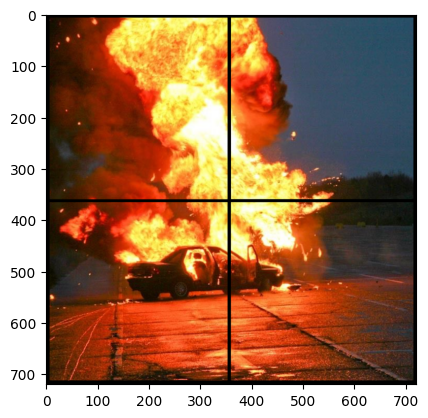

In [6]:
img = cv2.imread('Assets/Meledak.png')
meletup = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mp.imshow(meletup, cmap='gray')

Kode ini digunakan untuk melakukan proses cropping atau pemotongan citra menjadi empat bagian berbeda menggunakan teknik slicing array pada NumPy. Variabel meletup1, meletup2, meletup3, dan meletup4 masing-masing menyimpan bagian citra berdasarkan rentang koordinat baris dan kolom tertentu. Proses ini bertujuan untuk membagi gambar menjadi beberapa area agar setiap bagian dapat dianalisis atau diproses secara terpisah. 

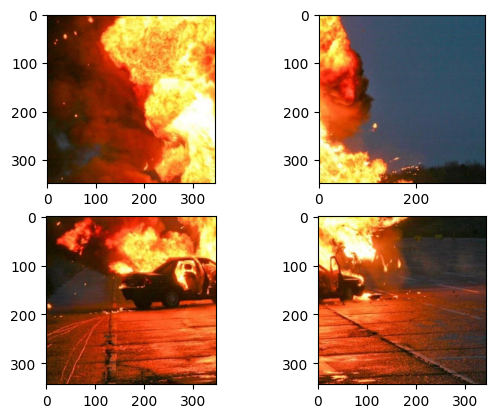

In [7]:
meletup1 = meletup[5:352, 5:352]
meletup2 = meletup[5:352, 367:710]
meletup3 = meletup[367:710, 5:352]
meletup4 = meletup[367:710, 367:710]

mp.subplot(2,2,1)
mp.imshow(meletup1, cmap='gray')
mp.subplot(2,2,2)
mp.imshow(meletup2, cmap='gray')
mp.subplot(2,2,3)
mp.imshow(meletup3, cmap='gray')
mp.subplot(2,2,4)
mp.imshow(meletup4, cmap='gray')

Kode ini digunakan untuk menggabungkan kembali empat bagian citra hasil cropping menjadi satu gambar utuh menggunakan fungsi merge_image(). Penggabungan pertama dilakukan secara horizontal ('H') antara meletup1 dengan meletup2, serta meletup3 dengan meletup4. Setelah itu, kedua hasil penggabungan tersebut digabungkan kembali secara vertikal ('V') sehingga membentuk satu citra lengkap seperti gambar awal.

Selanjutnya, fungsi cv2.cvtColor() digunakan untuk mengubah citra hasil penggabungan dari format RGB menjadi citra skala abu-abu (grayscale) menggunakan parameter cv2.COLOR_RGB2GRAY. Proses konversi ini bertujuan untuk menyederhanakan informasi warna menjadi intensitas keabuan sehingga mempermudah proses analisis citra.

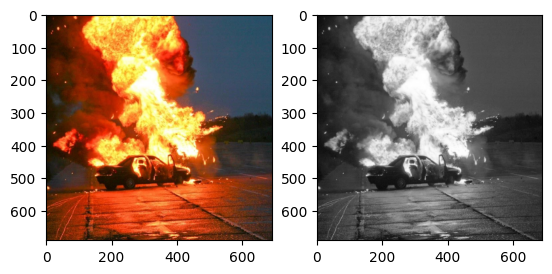

In [8]:
meletupgabung1 = merge_image(meletup1, meletup2, 'H')
meletupgabung2 = merge_image(meletup3, meletup4, 'H')
meletupgabung = merge_image(meletupgabung1, meletupgabung2,'V')

meletupabu = cv2.cvtColor(meletupgabung, cv2.COLOR_RGB2GRAY)
mp.subplot(1,2,1)
mp.imshow(meletupgabung)
mp.subplot(1,2,2)
mp.imshow(meletupabu, cmap='gray')

Kode ini digunakan untuk melakukan proses ekualisasi histogram pada citra grayscale yang disimpan pada variabel meletupabu. Fungsi ekualisasi() bertujuan untuk meningkatkan kualitas citra dengan memperbaiki distribusi intensitas piksel agar kontras gambar menjadi lebih jelas dan merata. Hasil proses ekualisasi kemudian disimpan ke dalam variabel

Shape gambar: (690, 690)


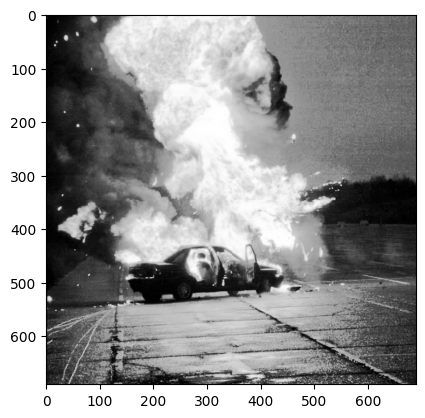

In [9]:
eq = ekualisasi(meletupabu)
print(f"Shape gambar: {eq.shape}")
mp.imshow(eq, cmap='gray')

Kode ini digunakan untuk membandingkan histogram citra sebelum dan sesudah proses ekualisasi histogram. Variabel blmeq digunakan untuk menyimpan histogram citra asli grayscale (meletupabu), sedangkan variabel sdheq menyimpan histogram citra hasil ekualisasi (eq). Kedua histogram tersebut diperoleh menggunakan fungsi buat_hist() yang menghitung jumlah kemunculan setiap intensitas piksel pada citra. Fungsi plot_histogram2() kemudian digunakan untuk menampilkan kedua histogram dalam satu grafik yang sama. Histogram citra sebelum ekualisasi ditampilkan dengan warna hijau sesuai parameter 'green', sedangkan histogram citra setelah ekualisasi ditampilkan dengan warna merah.

<Figure size 1000x500 with 0 Axes>

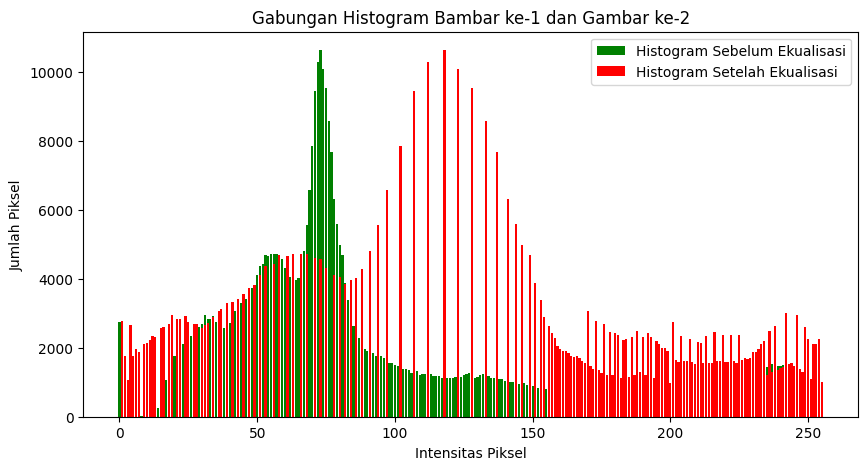

In [10]:
blmeq = buat_hist(meletupabu)
sdheq = buat_hist(eq)
mp.figure(figsize=(10,5))
plot_histogram2(blmeq, sdheq, 'Gabungan Histogram Bambar ke-1 dan Gambar ke-2', 'green')

Kode ini digunakan untuk melakukan proses spesifikasi histogram pada citra digital. Pertama, gambar Windut.png dibaca menggunakan fungsi cv2.imread() dan disimpan ke dalam variabel windut. Selanjutnya, citra tersebut diubah menjadi citra skala abu-abu (grayscale) menggunakan fungsi cv2.cvtColor() dengan parameter cv2.COLOR_BGR2GRAY, kemudian hasilnya disimpan pada variabel windutgrey.

Selain itu, gambar Bunga.png juga dibaca menggunakan fungsi cv2.imread() dan digunakan sebagai citra referensi dalam proses spesifikasi histogram. Fungsi spesifikasi_histogram() kemudian digunakan untuk mengubah distribusi histogram citra windutgrey agar menyerupai distribusi histogram dari citra bunga. Hasil proses tersebut disimpan pada variabel spec.

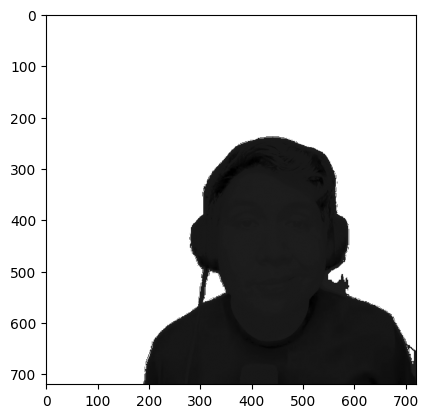

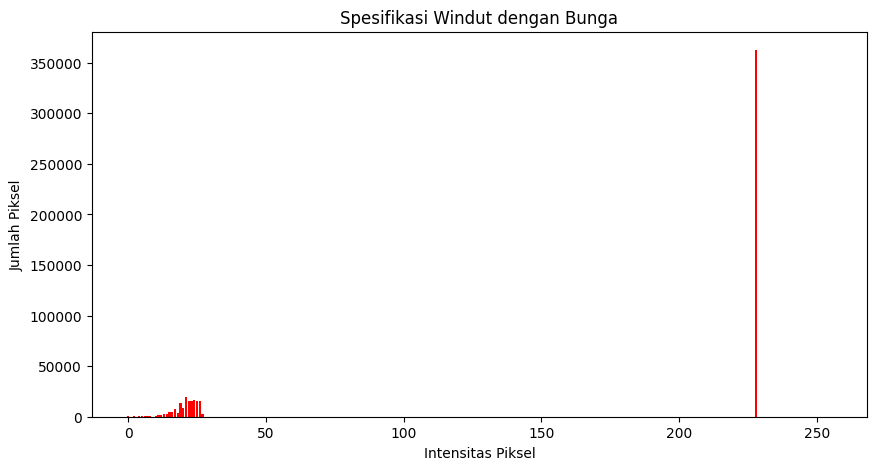

In [ ]:
windut = cv2.imread('Assets/Windut.png')
windutgrey = cv2.cvtColor(windut, cv2.COLOR_BGR2GRAY)
bunga = cv2.imread('Assets/Bunga.png')
spec = spesifikasi_histogram(windutgrey, bunga)
histspec = buat_hist(spec) 
mp.imshow(spec, cmap='gray')
plot_histogram(histspec, "Spesifikasi Windut dengan Bunga", 'red')

Kode ini digunakan untuk melakukan proses masking citra berdasarkan nilai threshold tertentu. Pertama, citra eq di-resize agar ukurannya sama dengan citra spec. Selanjutnya, dilakukan pengecekan setiap piksel pada citra spec. Jika nilai piksel lebih besar dari 90, maka piksel akan diganti menggunakan piksel dari citra bg, sedangkan nilai lainnya tetap menggunakan piksel asli.

Hasil masking kemudian ditampilkan menggunakan mp.imshow(). Setelah itu, citra hasil sebelumnya di-resize kembali agar sesuai dengan ukuran windutgrey dan dilakukan proses masking kedua menggunakan threshold sebesar 225. Proses ini bertujuan untuk mengganti bagian latar belakang citra berdasarkan intensitas piksel tertentu sehingga menghasilkan kombinasi gambar yang baru.

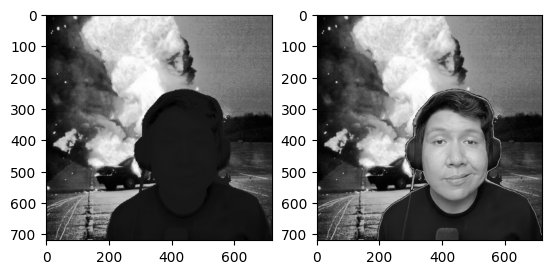

In [12]:
# masking1
bg = cv2.resize(eq, (spec.shape[1], spec.shape[0]))
masking = np.zeros_like(img)

for i in range(spec.shape[0]):
    for j in range(spec.shape[1]):
        if spec[i, j] > 90:  # threshold bisa disesuaikan
            masking[i, j] = bg[i, j]
        else:
            masking[i, j] = spec[i, j]

# masking2
jadi = cv2.resize(masking, (windutgrey.shape[1], windutgrey.shape[0]))
masking2 = np.zeros_like(img)

for i in range(windutgrey.shape[0]):
    for j in range(windutgrey.shape[1]):
        if windutgrey[i, j] > 225:  # threshold bisa disesuaikan
            masking2[i, j] = jadi[i, j]
        else:
            masking2[i, j] = windutgrey[i, j]

mp.subplot(1,2,1)
mp.imshow(masking, cmap='gray')
mp.subplot(1,2,2)
mp.imshow(masking2, cmap='gray')

Kode ini digunakan untuk membaca citra Langit.png menggunakan fungsi cv2.imread(), kemudian mengubahnya menjadi citra grayscale menggunakan cv2.cvtColor(). Setelah itu, fungsi spesifikasi_histogram() digunakan untuk menyesuaikan distribusi histogram citra masking2 agar menyerupai histogram citra langit. Hasil proses spesifikasi histogram disimpan pada variabel spec2 dan ditampilkan menggunakan mp.imshow() dengan parameter cmap='gray'.

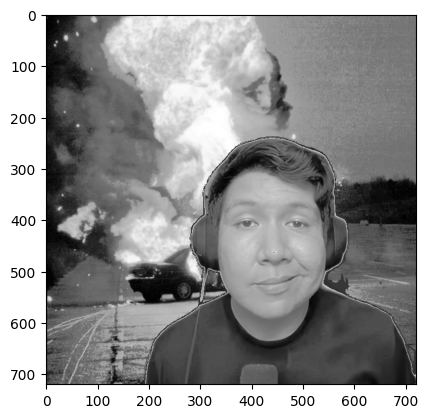

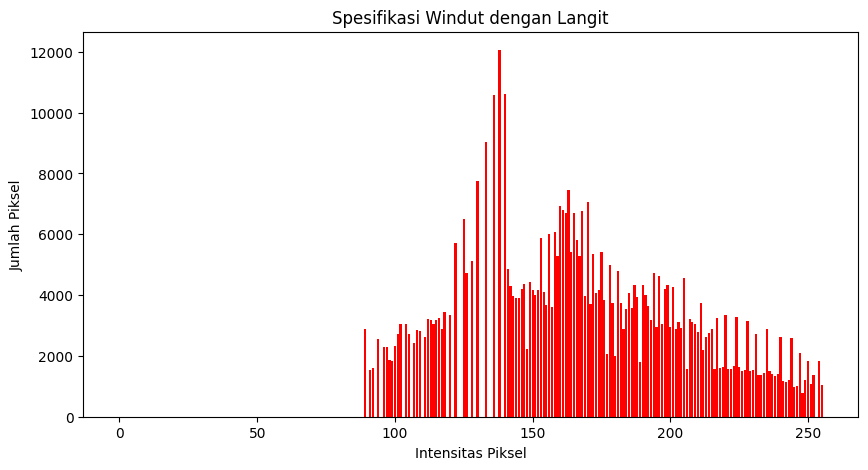

In [13]:
langit = cv2.imread('Assets/Langit.png')
langit = cv2.cvtColor(langit, cv2.COLOR_BGR2GRAY)

spec2 = spesifikasi_histogram(masking2, langit)
mp.imshow(spec2, cmap='gray')

windutlangit = buat_hist(spec2)
plot_histogram(windutlangit, 'Spesifikasi Windut dengan Langit', 'red')

Kode ini digunakan untuk melakukan proses masking pada citra berwarna dengan teknik seleksi berdasarkan nilai intensitas RGB. Citra meletupgabung terlebih dahulu di-resize agar ukurannya sama dengan citra windut. Setelah itu, dibuat array kosong menggunakan np.zeros_like() untuk menyimpan hasil proses.

Pada proses masking, setiap piksel pada citra windut diperiksa. Jika nilai kanal merah, hijau, dan biru lebih besar dari 245, maka piksel tersebut dianggap sebagai latar belakang berwarna sangat terang dan akan diganti menggunakan piksel dari citra gabungwarna. Jika kondisi tidak terpenuhi, maka piksel asli dari citra windut tetap digunakan.

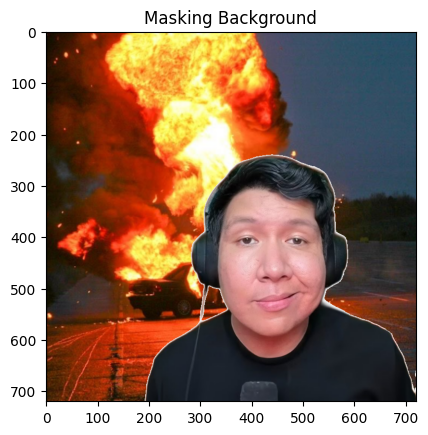

In [ ]:
gabungwarna = cv2.resize(meletupgabung, (windut.shape[1], windut.shape[0]))
mask = np.zeros_like(img)

for i in range(windut.shape[0]):
    for j in range(windut.shape[1]):

        if (
            windut[i,j,0] > 245 and
            windut[i,j,1] > 245 and
            windut[i,j,2] > 245
        ):

            mask[i,j] = gabungwarna[i,j]

        else:
            mask[i,j] = windut[i,j]

mp.imshow(mask)
mp.title("Masking Background")
mp.show()

Kode ini digunakan untuk mengubah komposisi warna pada citra mask dengan membuat efek blue tint. Pertama, dibuat array kosong menggunakan np.zeros_like() untuk menyimpan hasil manipulasi warna pada variabel windutwarna.

Selanjutnya, dilakukan pertukaran kanal warna RGB, di mana kanal merah diisi menggunakan nilai kanal biru lama, kanal hijau tetap dipertahankan, dan kanal biru diisi menggunakan nilai kanal merah lama. Proses ini menghasilkan perubahan dominasi warna pada citra sehingga tampilan gambar terlihat memiliki nuansa kebiruan.

Text(0.5, 1.0, 'Windut Cipularang')

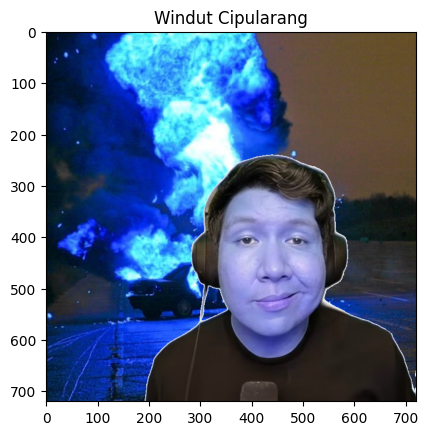

In [20]:
windutwarna = np.zeros_like(mask)
for i in range(mask.shape[0]):
    for j in range(mask.shape[1]):

        # BLUE TINT
        windutwarna[:,:,0] = mask[:,:,2]  # R = B lama
        windutwarna[:,:,1] = mask[:,:,1]  # G tetap
        windutwarna[:,:,2] = mask[:,:,0]

mp.imshow(windutwarna)
mp.title('Windut Cipularang')